# Approximator with `sklearn.linear_model.LinearRegression`

In [73]:
from types import NoneType

import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json

In [74]:
import sys, os
import platform
import sigmaepsilon.solid.fourier as fourier

print("Library version: ", fourier.__version__)

# Print Python version
print("Python version:", sys.version)

# Print OS information
print("Operating System:", platform.system(), platform.release())
print("Platform info:", platform.platform())

# Print processor and machine architecture
print("Processor:", platform.processor())
print("Machine:", platform.machine())

# Optionally, print the CPU core count
# (works in Python 3.4+, returns None if undetermined)
print("CPU Count:", os.cpu_count())

Library version:  2.1.0
Python version: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
Operating System: Darwin 23.4.0
Platform info: macOS-14.4-arm64-arm-64bit
Processor: arm
Machine: arm64
CPU Count: 11


In [ ]:
config_file_path = "config_rhs.json"
data_file_path = "data_rhs.csv"
model_file_path = "model_linreg_sklearn.pkl"

In [76]:
with open(config_file_path, "r") as f:
    config: dict = json.load(f)

In [77]:
# Load section data
section_data = config["section"]

section_variables = []
for p in section_data["params"].keys():
    if section_data["params"][p]["variable"]:
        section_variables.append(p)

load_components = ["n", "mxx", "myy", "vx", "vy", "mzz"]
predictor_columns = section_variables + load_components

target_columns = ["utilization", "area", "ixx", "iyy", "ixy", "g_eff"]

In [78]:
df = pd.read_csv(data_file_path)
df = df.dropna()
assert df.isnull().sum().max() == 0, "DataFrame still contains NaN values after dropping."
print("Number of rows after dropping NaNs:", len(df))
df.head(100)

Number of rows after dropping NaNs: 3720


,d,b,t,r_out,n_r,n,mxx,myy,vx,vy,mzz,area,ixx,iyy,ixy,g_eff,utilization,section_param_id,section_type
0,292.940338,184.123599,16.722934,17.628862,4,-688877.841108,-1.312324e+07,2.412614e+06,-115170.575087,13682.531592,1.153415e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.322426,0,rectangular_hollow_section
1,292.940338,184.123599,16.722934,17.628862,4,354570.903962,-2.555486e+07,-5.432602e+06,41320.270385,152295.668465,-2.124411e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.352120,0,rectangular_hollow_section
2,292.940338,184.123599,16.722934,17.628862,4,-487911.441850,-6.665061e+06,2.604899e+07,-240323.071707,238398.799619,-1.857385e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.762931,0,rectangular_hollow_section
3,292.940338,184.123599,16.722934,17.628862,4,-48213.704668,2.253705e+07,1.034981e+07,-233498.377101,-168306.320838,1.210748e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.647851,0,rectangular_hollow_section
4,292.940338,184.123599,16.722934,17.628862,4,-957990.414679,-5.910821e+06,9.593818e+06,17546.913768,-174641.502762,1.074127e+07,14527.235375,3.200690e+13,1.520191e+13,-0.265625,76923.076923,0.274913,0,rectangular_hollow_section
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,101.813572,109.591089,13.930502,10.252011,4,-564928.616997,1.622176e+07,2.614503e+07,175814.240826,-39441.351069,2.216032e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.077578,5,rectangular_hollow_section
116,101.813572,109.591089,13.930502,10.252011,4,-312441.445315,1.047845e+07,2.782598e+07,-214745.990821,29139.577702,-1.595956e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,0.945353,5,rectangular_hollow_section
117,101.813572,109.591089,13.930502,10.252011,4,160602.876633,1.547682e+07,-1.796579e+07,203558.739351,-52621.391867,-2.141584e+07,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.166064,5,rectangular_hollow_section
118,101.813572,109.591089,13.930502,10.252011,4,-261612.747473,5.105223e+06,1.758743e+07,243210.142476,-234825.931062,-6.338786e+06,5008.606822,1.327432e+12,1.502990e+12,0.010254,76923.076923,1.224112,5,rectangular_hollow_section


In [66]:
X = df[predictor_columns]
y = df[target_columns]
X.shape, y.shape

((3840, 10), (3840, 6))

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=df["section_param_id"]
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2572, 10)
Testing data shape: (1268, 10)


In [68]:
models = {}


def add_model(name:str, model:BaseEstimator, grid:dict | NoneType = None) -> None:
    steps = [
        ("scaling", StandardScaler()),
        ("regression", model)
    ]
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    models[name] = {"model": pipeline}
    if grid:
        models[name]["params_grid"] = grid
    

add_model("Linear Regression", LinearRegression())
add_model("Ridge Regression", Ridge(alpha=0.1), {"regression__alpha": np.arange(0.0001, 1, 10)})
add_model("Lasso Regression", Lasso(alpha=0.1), {"regression__alpha": np.arange(0.0001, 1, 10)})

models

{'Linear Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', LinearRegression())])},
 'Ridge Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', Ridge(alpha=0.1))]),
  'params_grid': {'regression__alpha': array([0.0001])}},
 'Lasso Regression': {'model': Pipeline(steps=[('scaling', StandardScaler()),
                  ('regression', Lasso(alpha=0.1))]),
  'params_grid': {'regression__alpha': array([0.0001])}}}

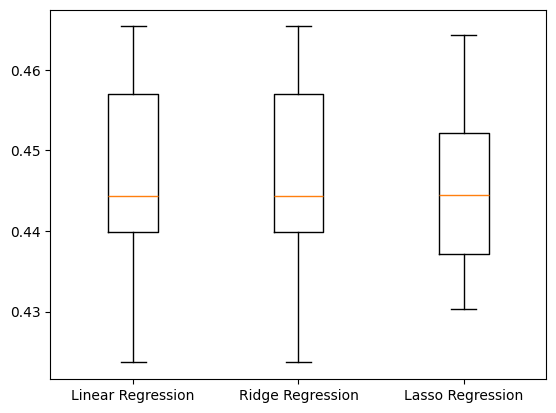

In [69]:
results = []
for model_name in models:
  model = models[model_name]["model"]
  
  # Define K-Fold cross-validation
  kf = KFold(n_splits=12, random_state=42, shuffle=True)
  
  # Perform cross-validation
  cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
  
  # Append the results
  results.append(cv_scores)

# Create a box plot of the results
plt.boxplot(results, tick_labels=models.keys())
plt.show()

In [70]:
for model in models:
    
    if not "param_grid" in models[model]:
        continue
        
    kf = KFold(n_splits=12, random_state=42, shuffle=True)
    param_grid = models[model]["param_grid"]
    cv = RandomizedSearchCV(models[model]["model"], param_grid, cv=kf, n_iter=4)
    cv.fit(X_train, y_train)

    models[model]["model"] = cv.best_estimator_

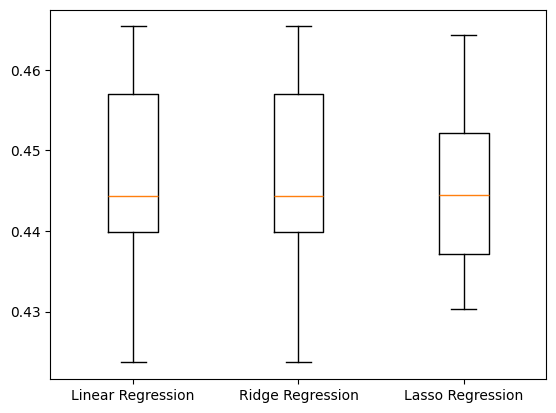

In [71]:
# perform cross validation on all the models for the box plot
results = []
for model_name in models:
    model = models[model_name]["model"]
    
    # Define K-Fold cross-validation
    kf = KFold(n_splits=12, random_state=42, shuffle=True)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf)
    
    # Append the results
    results.append(cv_scores)
    
    # Save the mean score
    models[model_name]["cv_mean"] = cv_scores.mean()

# Create a box plot of the results
plt.boxplot(results, tick_labels=models.keys())
plt.show()

In [72]:
best_model_name = max(models, key=lambda name: models[name].get("cv_mean", float('-inf')))
best_model = models[best_model_name]["model"]
print("Best model:", best_model_name)

with open(model_file_path, "wb") as f:
    joblib.dump(best_model, f, protocol=5)

Best model: Ridge Regression
